## 📊 Employee Promotion Prediction – Machine Learning Project Report

### 1. Project Overview

Employee promotion decisions are critical for organizational growth, employee motivation, and fairness.
However, relying solely on manual evaluation can introduce bias, inconsistency, and inefficiency.

This project applies data analysis and machine learning to study historical employee data and identify patterns associated with promotion.
The goal is to understand which features matter most and build a model that can recommend promotion eligibility as a decision-support tool for HR.


### 2. Problem Statement

The organization wants to answer the following questions:

What factors influence employee promotion?

Can we predict promotion eligibility using historical employee data?

Which features are most important in promotion decisions?

Business Objective:
Build an interpretable ML model that helps HR identify high-potential employees while minimizing the risk of missing deserving candidates.

Target Variable:
Promoted_or_Not

1 → Promoted

0 → Not promoted


### Importing dependencies

In [13]:
# Installing and Importing dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from category_encoders import TargetEncoder

In [14]:
import os
os.getcwd()


'C:\\Users\\kolad\\AI_ML_Project\\Promotion'

In [15]:
import os
os.listdir()



['.ipynb_checkpoints',
 'df_pro_cleaned_preproc.csv',
 'promotion_dataset.csv',
 'Promotion_Ml_2-Copy1.ipynb',
 'Promotion_Ml_2.ipynb']

In [23]:
# Loading the data from the directory
df_pro = pd.read_csv("C:\\Users\\kolad\OneDrive\\Documents\\Data Class\\Data Fusion data\\Data science\\Churn_Promotion\\promotion_dataset.csv")

In [25]:
# Look at the first few rows

df_pro.head()

,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not
0,YAK/S/00001,Commercial Sales and Marketing,MSc MBA and PhD,Female,Direct Internal process,2,1986,12.5,2011,1,0,41,ANAMBRA,No,Married,No,No,0,0
1,YAK/S/00002,Customer Support and Field Operations,First Degree or HND,Male,Agency and others,2,1991,12.5,2015,0,0,52,ANAMBRA,Yes,Married,No,No,0,0
2,YAK/S/00003,Commercial Sales and Marketing,First Degree or HND,Male,Direct Internal process,2,1987,7.5,2012,0,0,42,KATSINA,Yes,Married,No,No,0,0
3,YAK/S/00004,Commercial Sales and Marketing,First Degree or HND,Male,Agency and others,3,1982,2.5,2009,0,0,42,NIGER,Yes,Single,No,No,1,0
4,YAK/S/00006,Information and Strategy,First Degree or HND,Male,Direct Internal process,3,1990,7.5,2012,0,0,77,AKWA IBOM,Yes,Married,No,No,1,0


### 3. Data Description

The dataset contains employee-level information across demographics, performance, training, and work history.

Key Feature Categories

Demographic Features: Gender, Marital_Status, State_Of_Origin, Foreign_schooled, 

Education & Recruitment: Qualification, Channel_of_Recruitment, Year_of_birth, Year_of_recruitment

Performance & Training: Last_performance_score, Targets_met,Previous_Award, Trainings_Attended, Training_score_average

Work History: Division, No_of_previous_employers, Past_Disciplinary_Action, Previous_IntraDepartmental_Movement

In [28]:
#checking the promotion dataset shape

df_pro.shape

(38312, 19)

The promotion dataset has 38,312 records and 19 features

In [32]:
df_pro.columns

Index(['EmployeeNo', 'Division', 'Qualification', 'Gender',
       'Channel_of_Recruitment', 'Trainings_Attended', 'Year_of_birth',
       'Last_performance_score', 'Year_of_recruitment', 'Targets_met',
       'Previous_Award', 'Training_score_average', 'State_Of_Origin',
       'Foreign_schooled', 'Marital_Status', 'Past_Disciplinary_Action',
       'Previous_IntraDepartmental_Movement', 'No_of_previous_employers',
       'Promoted_or_Not'],
      dtype='object')

### 3. Data Collection and Preparation

3.1 Data Cleaning

Checked data types and corrected numeric columns


In [33]:
df_pro.dtypes

EmployeeNo                              object
Division                                object
Qualification                           object
Gender                                  object
Channel_of_Recruitment                  object
Trainings_Attended                       int64
Year_of_birth                            int64
Last_performance_score                 float64
Year_of_recruitment                      int64
Targets_met                              int64
Previous_Award                           int64
Training_score_average                   int64
State_Of_Origin                         object
Foreign_schooled                        object
Marital_Status                          object
Past_Disciplinary_Action                object
Previous_IntraDepartmental_Movement     object
No_of_previous_employers                 int64
Promoted_or_Not                          int64
dtype: object

Year_of_birth → I will later convert to age

Division, Gender, Qualification, State_Of_Origin (These categorical features will need encoding later to be converted numbers so the ML models can use them)

> Target column (Promoted_or_Not)

### 4. Exploratory Data Analysis (EDA)



In [34]:
# Statisitical Analysis on df_pro

df_pro.describe().T

,count,mean,std,min,25%,50%,75%,max
Trainings_Attended,38312.0,2.253680,0.609443,2.0,2.0,2.0,2.0,11.0
Year_of_birth,38312.0,1986.209334,7.646047,1950.0,1982.0,1988.0,1992.0,2001.0
Last_performance_score,38312.0,7.698959,3.744135,0.0,5.0,7.5,10.0,12.5
Year_of_recruitment,38312.0,2013.139695,4.261451,1982.0,2012.0,2014.0,2016.0,2018.0
Targets_met,38312.0,0.352996,0.477908,0.0,0.0,0.0,1.0,1.0
Previous_Award,38312.0,0.023152,0.150388,0.0,0.0,0.0,0.0,1.0
Training_score_average,38312.0,55.366465,13.362741,31.0,43.0,52.0,68.0,91.0
No_of_previous_employers,38312.0,1.040953,1.235738,0.0,0.0,1.0,1.0,6.0
Promoted_or_Not,38312.0,0.084595,0.278282,0.0,0.0,0.0,0.0,1.0


#### View Unique Values for certain selected Categorical Column

In [35]:
# Manually select some columns 
sel_columns = [
    
    'Gender',
    'Channel_of_Recruitment',
    'Qualification',
    'Targets_met',
    'Previous_Award',
    'Foreign_schooled',
    'Marital_Status',
    'Past_Disciplinary_Action',
    'Previous_IntraDepartmental_Movement',
    'No_of_previous_employers',
    'Promoted_or_Not' 
    
]


In [36]:
# Loop through selected columns only
for col in sel_columns:
    print(f"Column: {col}")
    print("Unique values:")
    print(df_pro[col].value_counts(dropna=False).head(10))  # includes NaN
 
    
    print("=" * 40)


Column: Gender
Unique values:
Male      26880
Female    11432
Name: Gender, dtype: int64
Column: Channel_of_Recruitment
Unique values:
Agency and others                  21310
Direct Internal process            16194
Referral and Special candidates      808
Name: Channel_of_Recruitment, dtype: int64
Column: Qualification
Unique values:
First Degree or HND         25578
MSc  MBA and PhD            10469
NaN                          1679
Non University Education      586
Name: Qualification, dtype: int64
Column: Targets_met
Unique values:
0    24788
1    13524
Name: Targets_met, dtype: int64
Column: Previous_Award
Unique values:
0    37425
1      887
Name: Previous_Award, dtype: int64
Column: Foreign_schooled
Unique values:
Yes    34995
No      3317
Name: Foreign_schooled, dtype: int64
Column: Marital_Status
Unique values:
Married     31022
Single       6927
Not_Sure      363
Name: Marital_Status, dtype: int64
Column: Past_Disciplinary_Action
Unique values:
No     38161
Yes      151
Name

> The organization is dominated by males as the males are twice the females. Also, majority of our employees are married.

> The channel of recruitment is more through Agency and others, followed by direct internal process.

> Over 70% of the employees are First degree/HND owners while about **1679 had null values** for their qualification

> Over 90% of the employees schooled outside the country

> Majority of the employees also don't have past disciplinary action, neither have they been previously  and have not experienced interdepartmental movement

> Over 90% of the employees haven't experienced promotion also


### 4.1 Data Cleaning and Preprocessing

#### Checking for Missing Values

In [37]:
df_pro.isnull().sum()

EmployeeNo                                0
Division                                  0
Qualification                          1679
Gender                                    0
Channel_of_Recruitment                    0
Trainings_Attended                        0
Year_of_birth                             0
Last_performance_score                    0
Year_of_recruitment                       0
Targets_met                               0
Previous_Award                            0
Training_score_average                    0
State_Of_Origin                           0
Foreign_schooled                          0
Marital_Status                            0
Past_Disciplinary_Action                  0
Previous_IntraDepartmental_Movement       0
No_of_previous_employers                  0
Promoted_or_Not                           0
dtype: int64

We have 1679 missing values from the Qualification feature which has 3 categories. let's inspect why

### 4.2 Relationship between missing data and other variables

In [38]:
# Total count of promotion dataset

total = len(df_pro)

missing_count = df_pro['Qualification'].isna().sum()
print(f"Total rows: {total}, Qualification missing count: {missing_count} ")

Total rows: 38312, Qualification missing count: 1679 


In [39]:
# Preview rows with missing qualifications 

df_pro[df_pro['Qualification'].isna()].head()

,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not
15,YAK/S/00022,Customer Support and Field Operations,NaN,Male,Direct Internal process,2,1980,10.0,2008,0,0,49,RIVERS,Yes,Married,No,No,1,0
22,YAK/S/00033,Commercial Sales and Marketing,NaN,Female,Direct Internal process,2,1997,2.5,2017,0,0,40,EDO,Yes,Married,No,No,1,0
28,YAK/S/00044,Commercial Sales and Marketing,NaN,Male,Agency and others,4,1997,5.0,2017,0,0,40,CROSS RIVER,Yes,Married,No,No,1,0
60,YAK/S/00091,Commercial Sales and Marketing,NaN,Female,Direct Internal process,2,2001,0.0,2018,0,0,47,ZAMFARA,Yes,Single,No,No,2,0
137,YAK/S/00190,Customer Support and Field Operations,NaN,Female,Agency and others,2,1988,10.0,2010,0,0,56,LAGOS,Yes,Single,No,No,5,0


In [40]:
# Are missing qaulification rows heavily reliant on division or gender

print(df_pro.groupby('Division')['Qualification'].apply(lambda s: s.isna().sum()).sort_values(ascending=False).head(10))
print(df_pro.groupby('Gender')['Qualification'].apply(lambda s: s.isna().sum()).sort_values(ascending=False))

Division
Commercial Sales and Marketing                 1096
Information and Strategy                        230
Customer Support and Field Operations           169
Information Technology and Solution Support      62
Sourcing and Purchasing                          49
Business Finance Operations                      28
People/HR Management                             22
Research and Innovation                          19
Regulatory and Legal services                     4
Name: Qualification, dtype: int64
Gender
Male      1409
Female     270
Name: Qualification, dtype: int64


Majority of those with missing qualifications belong to the **commercial sales and marketing division** and they are mostly males.

In [41]:
# Compare promotion rate for missing vs non-missing
promo_by_qual_missing = df_pro.assign(Q_missing = df_pro['Qualification'].isna())\
                                .groupby('Q_missing')['Promoted_or_Not'].agg(['count','mean'])

print(promo_by_qual_missing)

           count      mean
Q_missing                 
False      36633  0.086234
True        1679  0.048839


The missing value sis about 4.38% of the data. Although not dominant, yet its significant.

From the mean, Employees with missing Qualification have a significantly lower promotion rate (4.88%) compared to those with provided Qualification (8.62%). This indicates that missingness is informative and should not be blindly imputed. Instead, a missing-indicator variable was created and Qualification feature was filled with the category “Unknown”.

#### 4.3 Create a missing-indicator feature

In [42]:

df_pro['Qualification_missing'] = df_pro['Qualification'].isna().astype(int)


In [43]:
# Fillinf the missing Qualification values with unknown

df_pro['Qualification'].fillna('Unknown', inplace=True)


In [44]:
df_pro.tail()

,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not,Qualification_missing
38307,YAK/S/54802,Information Technology and Solution Support,First Degree or HND,Female,Direct Internal process,2,1990,0.0,2018,0,0,70,LAGOS,Yes,Married,No,No,0,0,0
38308,YAK/S/54805,Customer Support and Field Operations,MSc MBA and PhD,Female,Agency and others,2,1984,5.0,2013,0,0,48,IMO,Yes,Married,No,No,1,0,0
38309,YAK/S/54806,Information and Strategy,First Degree or HND,Male,Agency and others,2,1994,12.5,2016,1,0,71,ANAMBRA,No,Married,No,No,3,0,0
38310,YAK/S/54807,Commercial Sales and Marketing,Unknown,Male,Direct Internal process,2,1992,2.5,2017,0,0,37,KWARA,Yes,Married,No,No,1,0,1
38311,YAK/S/54808,People/HR Management,First Degree or HND,Male,Agency and others,2,1994,2.5,2014,0,0,41,KWARA,Yes,Single,No,No,2,0,0


In [45]:
# Re-checking for missing values

df_pro.isnull().sum().to_frame('missing_count')

,missing_count
EmployeeNo,0
Division,0
Qualification,0
Gender,0
Channel_of_Recruitment,0
Trainings_Attended,0
Year_of_birth,0
Last_performance_score,0
Year_of_recruitment,0
Targets_met,0


#### 4.4 Checking for Duplicates

In [46]:
# Full-row duplicates
dup_rows = df_pro.duplicated()
print("Full-row duplicates:", dup_rows.sum())

Full-row duplicates: 0


In [47]:
# Duplicates by EmployeeNo (important: EmployeeNo is an ID; duplicates often indicate data issues)
if 'EmployeeNo' in df_pro.columns:
    dup_id = df_pro.duplicated(subset=['EmployeeNo'], keep=False)
    print("Rows with duplicate EmployeeNo:", dup_id.sum())
    display(df_pro[dup_id].sort_values('EmployeeNo').head(20))
else:
    print("No EmployeeNo column found.")

Rows with duplicate EmployeeNo: 0


,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,Previous_Award,Training_score_average,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not,Qualification_missing


#### Looking into the target column 'promoted or not'

#### Promotion by Division

In [48]:
promo_div = (
    df_pro
    .groupby('Division')['Promoted_or_Not']
    .agg(['count','mean'])
    .sort_values('mean', ascending=False)
)

promo_div


,count,mean
Division,,
Information Technology and Solution Support,4952,0.107431
Sourcing and Purchasing,5052,0.096793
Information and Strategy,3721,0.093523
Customer Support and Field Operations,7973,0.088298
Business Finance Operations,1786,0.081747
Commercial Sales and Marketing,11695,0.071911
Research and Innovation,696,0.061782
People/HR Management,1704,0.056925
Regulatory and Legal services,733,0.055935


#### Promotion by Qualification

In [49]:
promo_qual = (
    df_pro
    .groupby(df_pro['Qualification'].fillna('Unknown'))['Promoted_or_Not']
    .agg(['count','mean'])
    .sort_values('mean', ascending=False)
)

promo_qual


,count,mean
Qualification,,
MSc MBA and PhD,10469,0.096666
Non University Education,586,0.088737
First Degree or HND,25578,0.081906
Unknown,1679,0.048839


More persons with MSc MBA and PhD have the highest promotion, followed by Non University Education.

#### 4.5 Creating Age column from the Year of birth

In [50]:
# Creating Ages column from the provided years since its more interpretable

current_year = 2025
df_pro['Age'] = current_year - df_pro['Year_of_birth']

In [51]:
#Checking the Year of birth and recruitment columns

for col in ['Year_of_birth', 'Age','Year_of_recruitment']:
    if col in df_pro.columns:
        s = pd.to_numeric(df_pro[col], errors='coerce').dropna().astype(int)
        print(col, "min:", s.min(), "max:", s.max(), "median:", s.median(), "nulls:", df_pro[col].isnull().sum())


Year_of_birth min: 1950 max: 2001 median: 1988.0 nulls: 0
Age min: 24 max: 75 median: 37.0 nulls: 0
Year_of_recruitment min: 1982 max: 2018 median: 2014.0 nulls: 0


In [52]:
# Create Tenure column to know how long employee has been in the company

if 'Tenure' not in df_pro.columns and 'Year_of_recruitment' in df_pro.columns:
    df_pro['Tenure'] = 2025 - pd.to_numeric(df_pro['Year_of_recruitment'], errors='coerce')

In [53]:
# Preiviewing our modified data
df_pro.head()

,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,...,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not,Qualification_missing,Age,Tenure
0,YAK/S/00001,Commercial Sales and Marketing,MSc MBA and PhD,Female,Direct Internal process,2,1986,12.5,2011,1,...,ANAMBRA,No,Married,No,No,0,0,0,39,14
1,YAK/S/00002,Customer Support and Field Operations,First Degree or HND,Male,Agency and others,2,1991,12.5,2015,0,...,ANAMBRA,Yes,Married,No,No,0,0,0,34,10
2,YAK/S/00003,Commercial Sales and Marketing,First Degree or HND,Male,Direct Internal process,2,1987,7.5,2012,0,...,KATSINA,Yes,Married,No,No,0,0,0,38,13
3,YAK/S/00004,Commercial Sales and Marketing,First Degree or HND,Male,Agency and others,3,1982,2.5,2009,0,...,NIGER,Yes,Single,No,No,1,0,0,43,16
4,YAK/S/00006,Information and Strategy,First Degree or HND,Male,Direct Internal process,3,1990,7.5,2012,0,...,AKWA IBOM,Yes,Married,No,No,1,0,0,35,13


In [54]:
## Saving the cleaned copy of the data

df_pro.to_csv('df_pro_cleaned_preproc.csv', index=False)


#### 4.6 Visualise Numeric Columns

In [55]:
# Importing dependencies

import matplotlib.pyplot as plt

import seaborn as sns


In [56]:
df_pro.dtypes

EmployeeNo                              object
Division                                object
Qualification                           object
Gender                                  object
Channel_of_Recruitment                  object
Trainings_Attended                       int64
Year_of_birth                            int64
Last_performance_score                 float64
Year_of_recruitment                      int64
Targets_met                              int64
Previous_Award                           int64
Training_score_average                   int64
State_Of_Origin                         object
Foreign_schooled                        object
Marital_Status                          object
Past_Disciplinary_Action                object
Previous_IntraDepartmental_Movement     object
No_of_previous_employers                 int64
Promoted_or_Not                          int64
Qualification_missing                    int32
Age                                      int64
Tenure       

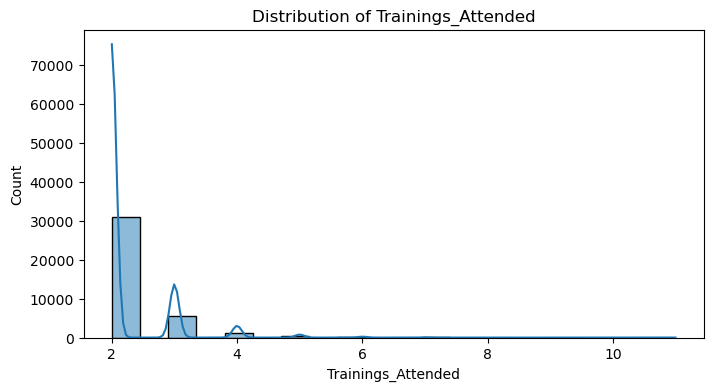

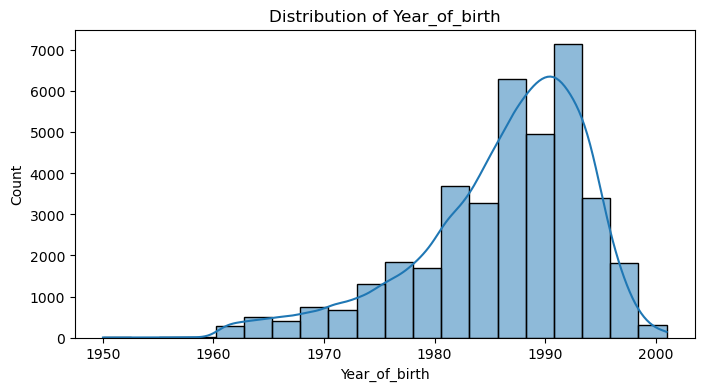

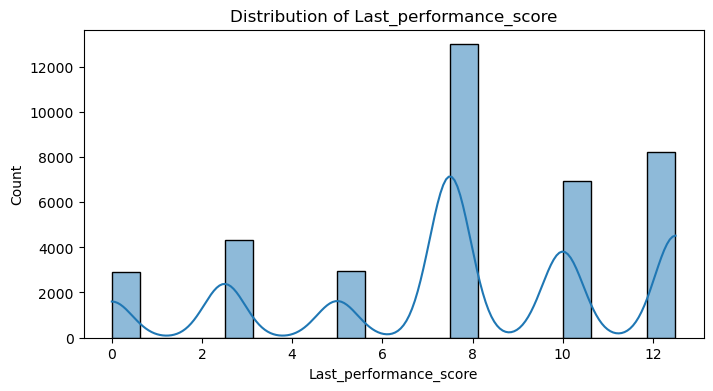

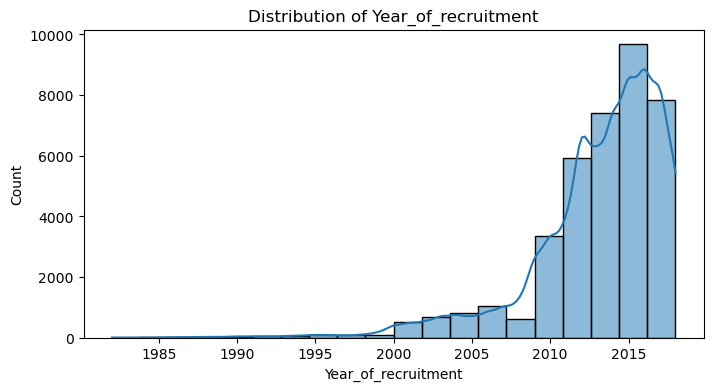

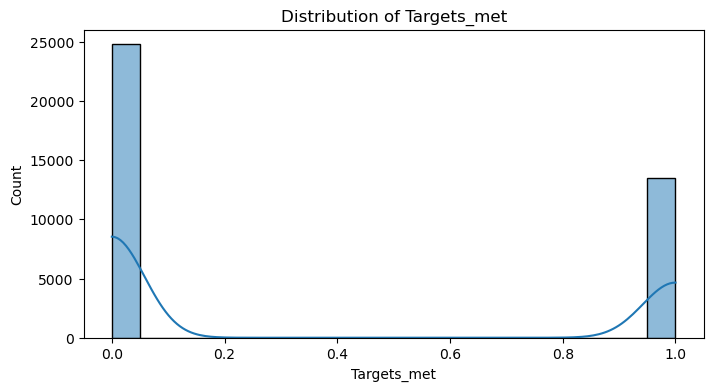

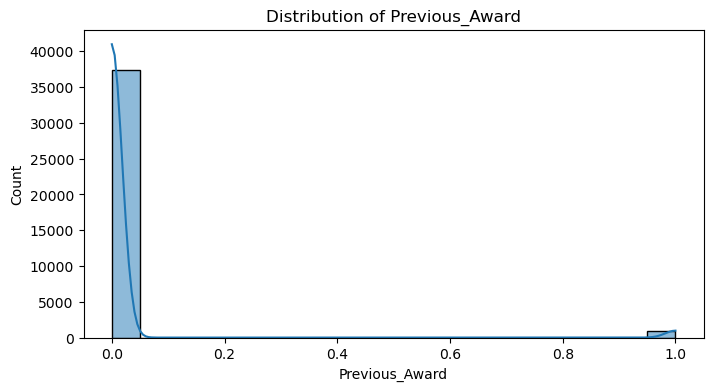

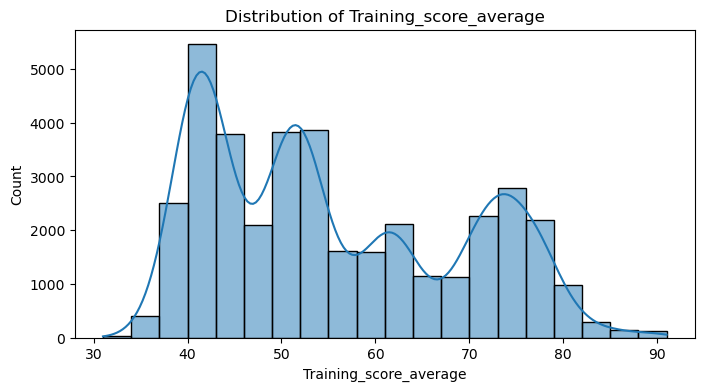

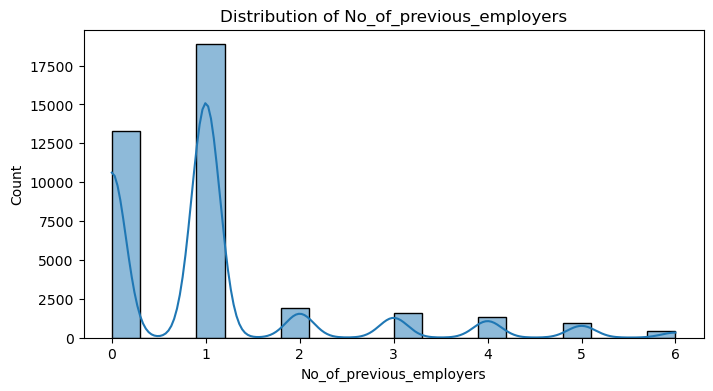

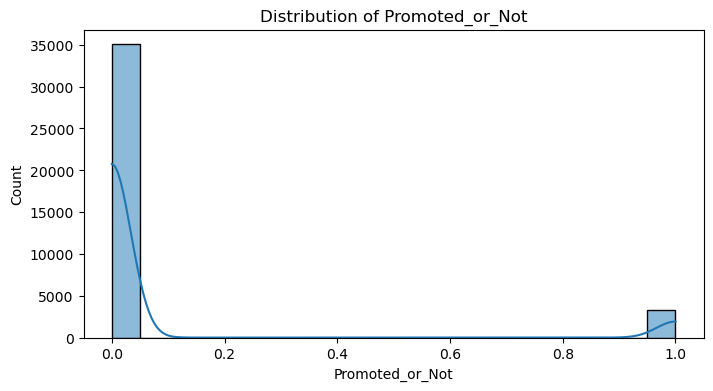

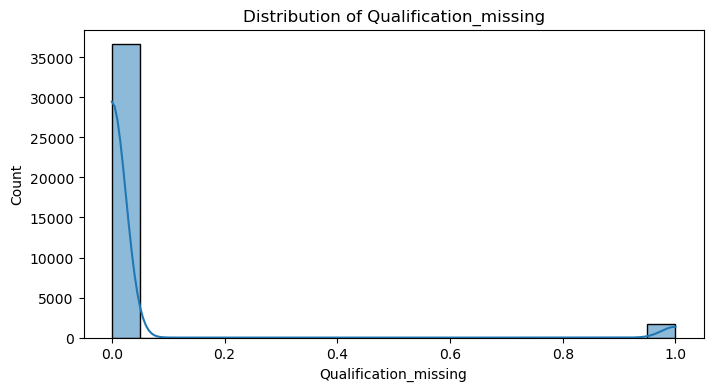

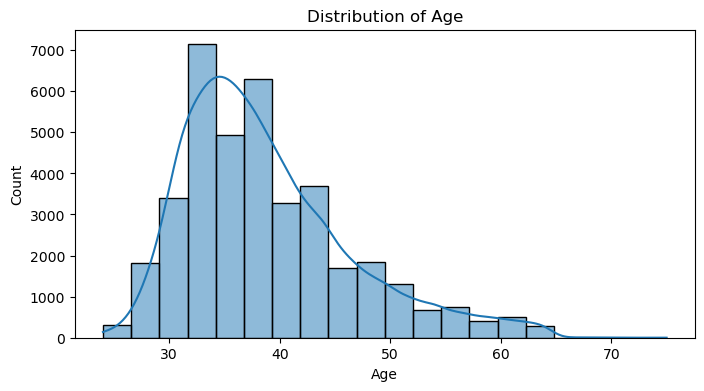

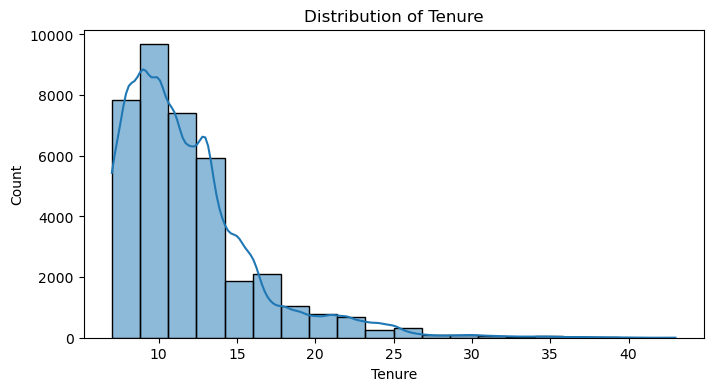

In [57]:
numeric_cols = df_pro.select_dtypes(include =['int64','int32','float64']).columns.tolist()
  
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df_pro[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
plt.show()

#### 4.7 Visualise Categorical Columns (object)

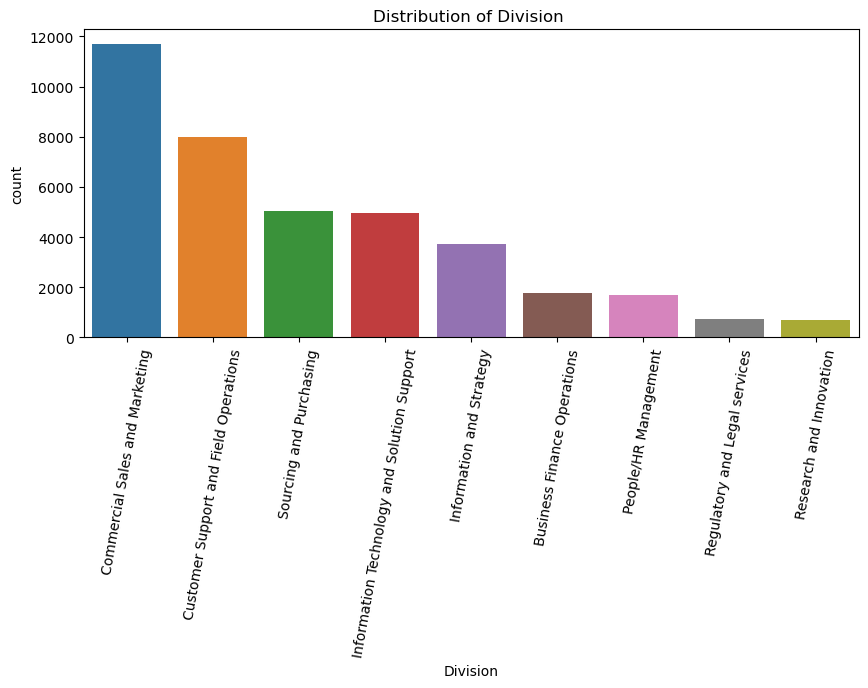

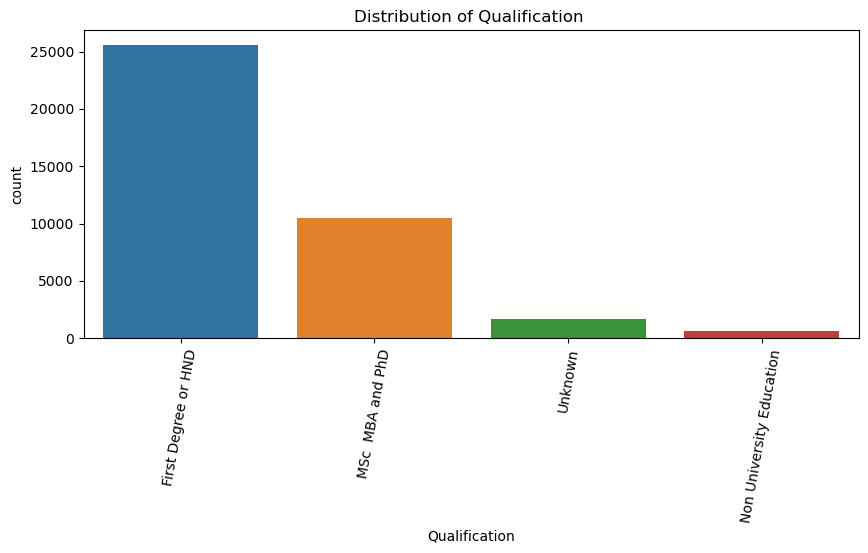

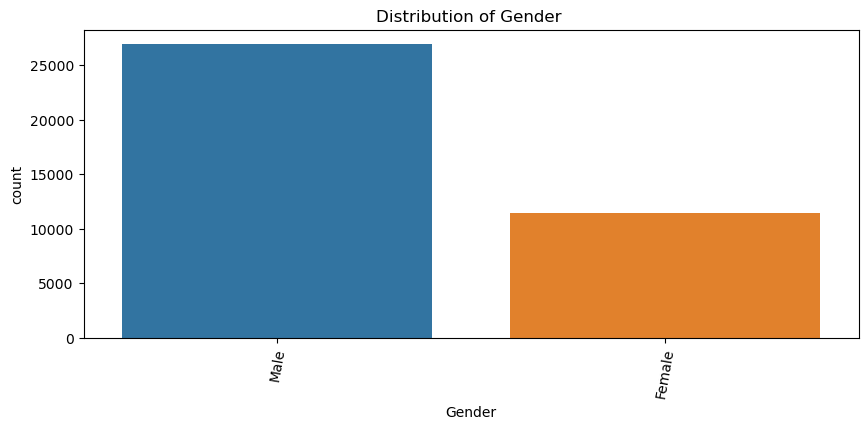

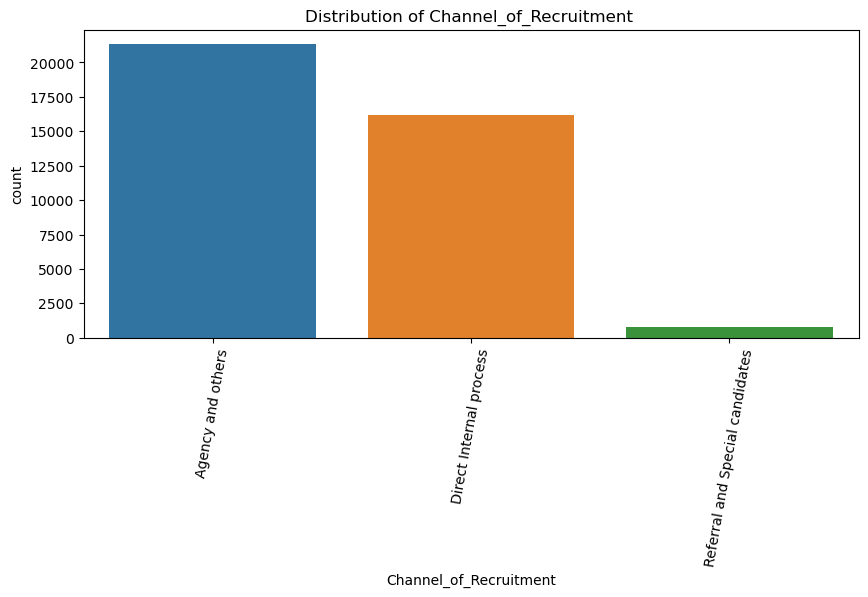

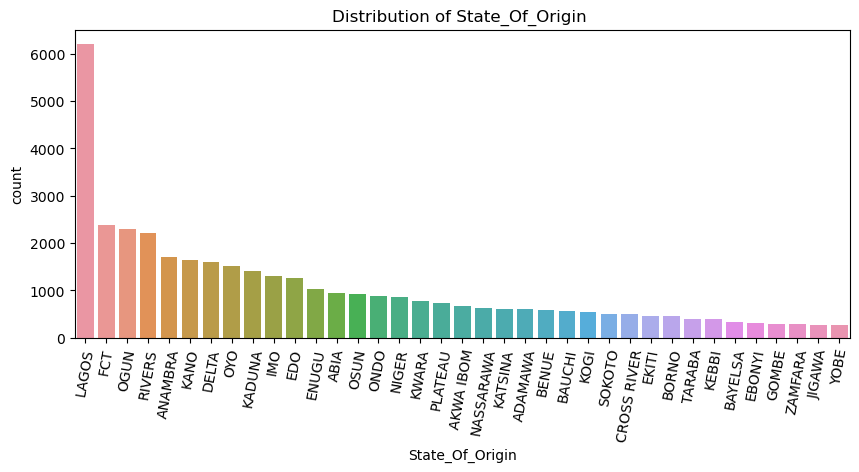

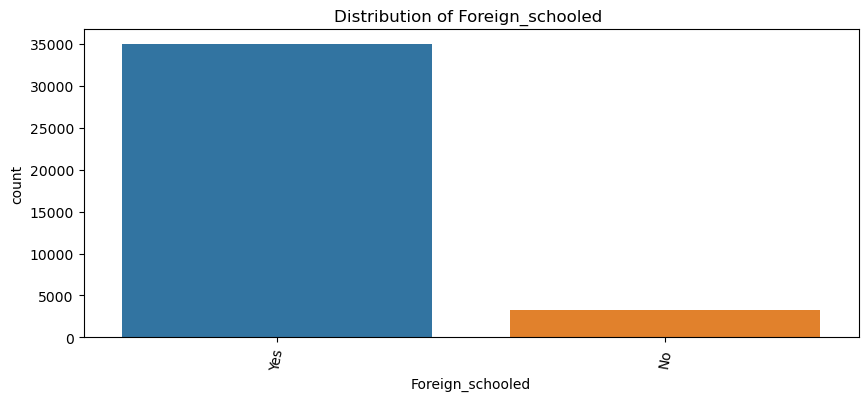

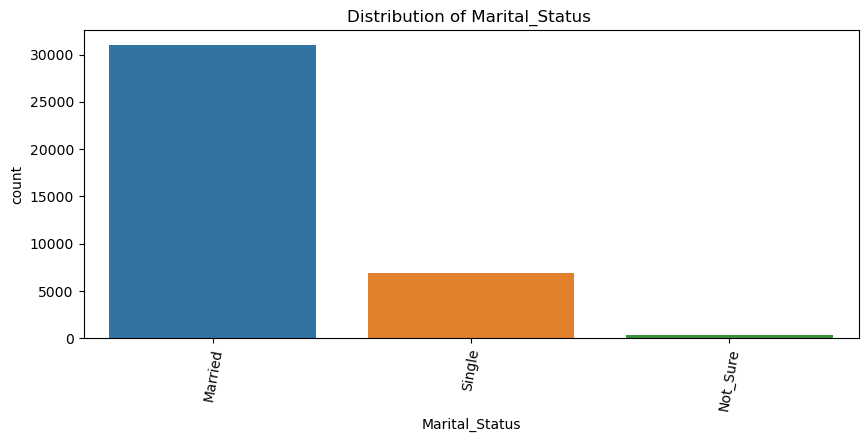

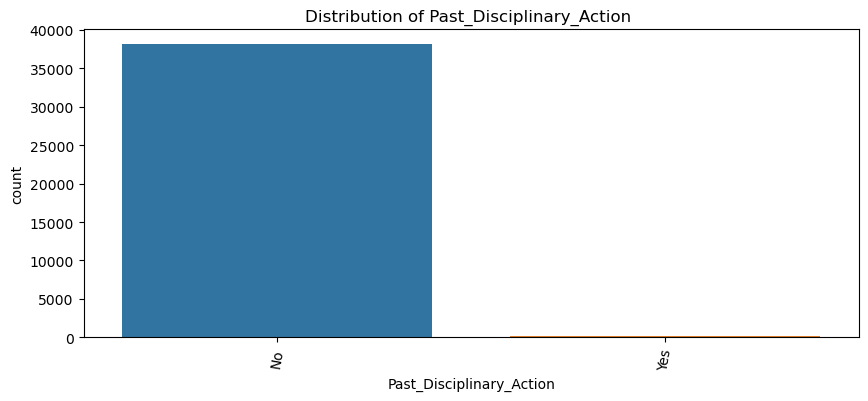

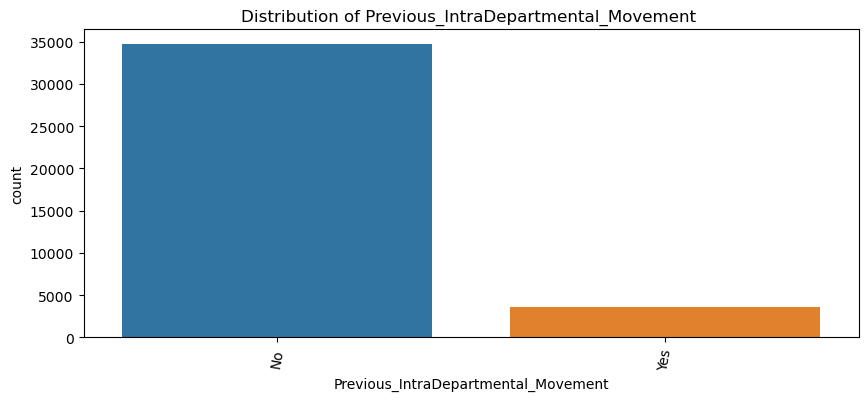

In [58]:
# Visualizing categorical columns

categorical_cols = df_pro.select_dtypes(include= 'object').columns.tolist()

#Removing EmployeeNo if it is in the list

if 'EmployeeNo' in categorical_cols:
    categorical_cols.remove('EmployeeNo')

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df_pro, x = col, order=df_pro[col].value_counts().index)
    plt.title(f"Distribution of {col} ")
    plt.xticks(rotation = 80)
    plt.show()

### 5. Mapping the individual features to the target variable-promotion

#### 5.1. Promotion rate by categorical features (Qualification, Division, Gender)


Promotion rate by Qualification


,count,mean
Qualification,,
MSc MBA and PhD,10469,0.096666
Non University Education,586,0.088737
First Degree or HND,25578,0.081906
Unknown,1679,0.048839


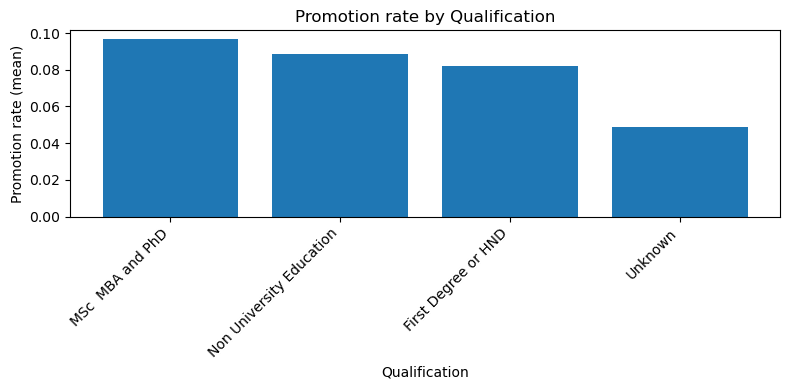


Promotion rate by Division


,count,mean
Division,,
Information Technology and Solution Support,4952,0.107431
Sourcing and Purchasing,5052,0.096793
Information and Strategy,3721,0.093523
Customer Support and Field Operations,7973,0.088298
Business Finance Operations,1786,0.081747
Commercial Sales and Marketing,11695,0.071911
Research and Innovation,696,0.061782
People/HR Management,1704,0.056925
Regulatory and Legal services,733,0.055935


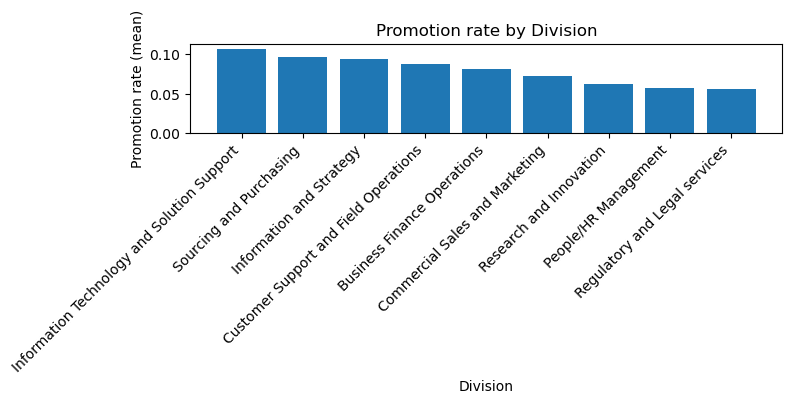


Promotion rate by Gender


,count,mean
Gender,,
Female,11432,0.089048
Male,26880,0.082701


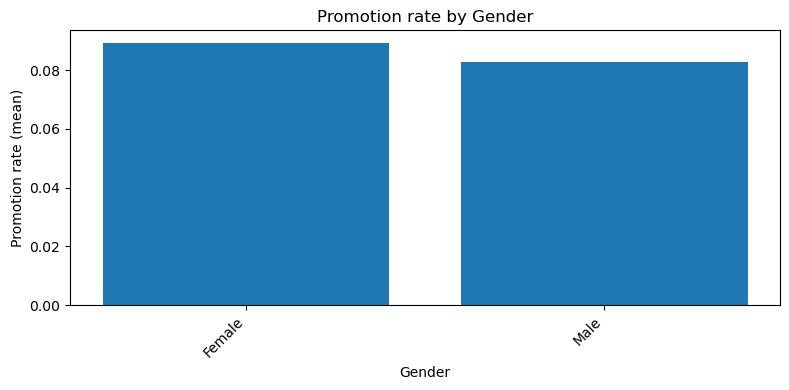

In [59]:
categorical_cols = [c for c in ['Qualification','Division','Gender'] if c in df_pro.columns]
target = 'Promoted_or_Not'

for col in categorical_cols:
    # prepare table
    grp = df_pro.groupby(df_pro[col].fillna('Missing'))[target].agg(['count','mean']).sort_values('mean', ascending=False)
    print("\nPromotion rate by", col)
    display(grp) # to display

    # plot promotion rate
    plt.figure(figsize=(8,4)) #get the chart size
    ax = plt.gca()
    ax.bar(grp.index.astype(str), grp['mean'])
    
    #Labelling the chart
    ax.set_title(f'Promotion rate by {col}')
    ax.set_ylabel('Promotion rate (mean)')
    ax.set_xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Qualification

> Employees with higher qualifications (MSc/MBA/PhD)-9.67% have the highest promotion rate, while Unknown (missing) is the lowest with 4.88%

### Gender

>  Females show a slightly higher promotion rate (0.63 percentage points), which is 8.9%. The difference is small.

### Division (top/bottom shown)

- Top: Information Technology & Solution Support — 10.74%

- Top: Sourcing and Purchasing — 9.68%

- Middle: Customer Support — 8.83%

- Bottom: Regulatory and Legal services — 5.59%

> Promotion rates vary across divisions — some divisions have noticeably higher promotion rate


#### Age vs Promotion (Boxplot Interpretation)

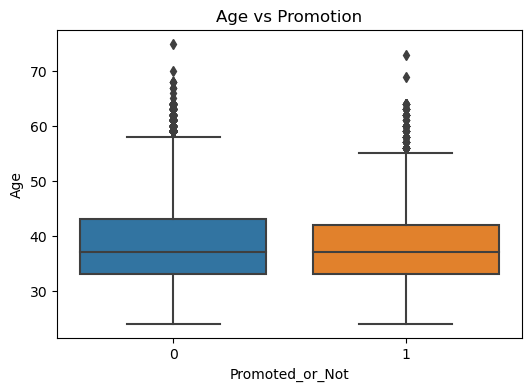

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='Promoted_or_Not', y='Age', data=df_pro)
plt.title('Age vs Promotion')
plt.show()


**Middle line --- Median Age are almost the same**

Not promoted (0) → ~36–37 years

Promoted (1) → ~37–38 years

**Age Spread --- (IQR - the Box)**

Both boxes cover roughly 32 to 42 years

Heavy overlap between promoted and not promoted groups

**Outliers**

Both groups have older employees (60–75 years)

No clear pattern that older employees are more promoted


> “The age distribution of promoted and non-promoted employees largely overlaps, with nearly identical median ages. This suggests that age alone is not a strong determinant of promotion, indicating that promotion decisions are likely driven by performance and organizational factors rather than employee age.”

In [61]:
df_pro.dtypes

EmployeeNo                              object
Division                                object
Qualification                           object
Gender                                  object
Channel_of_Recruitment                  object
Trainings_Attended                       int64
Year_of_birth                            int64
Last_performance_score                 float64
Year_of_recruitment                      int64
Targets_met                              int64
Previous_Award                           int64
Training_score_average                   int64
State_Of_Origin                         object
Foreign_schooled                        object
Marital_Status                          object
Past_Disciplinary_Action                object
Previous_IntraDepartmental_Movement     object
No_of_previous_employers                 int64
Promoted_or_Not                          int64
Qualification_missing                    int32
Age                                      int64
Tenure       

#### 4b. Histograms & KDE (numeric distributions by promotion status)

In [62]:
# Defining numeric columns

numeric_cols = ['Age', 'Tenure', 'Training_score_average','No_of_previous_employers','Trainings_Attended']
target = 'Promoted_or_Not'


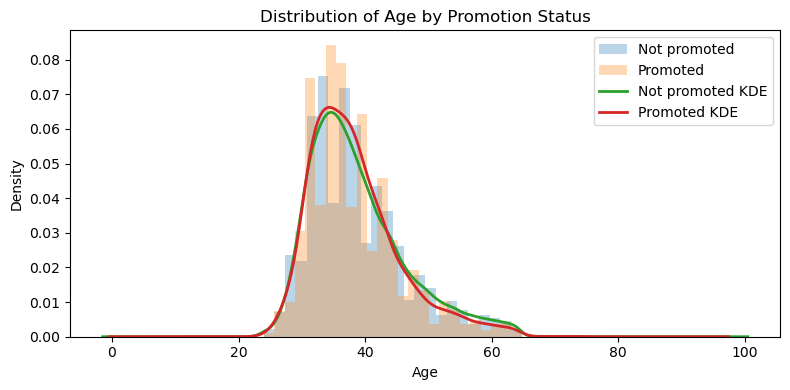

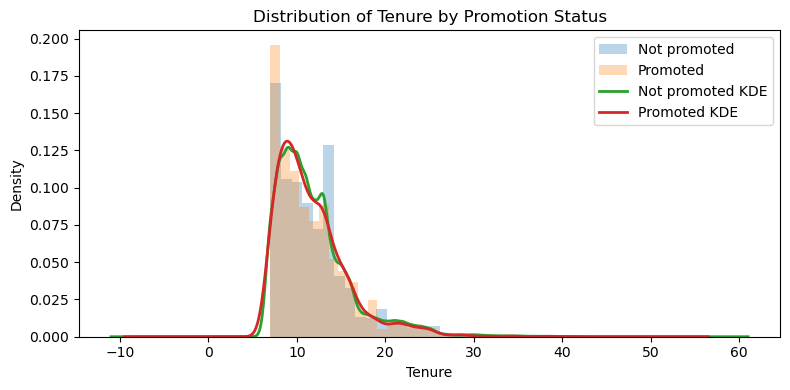

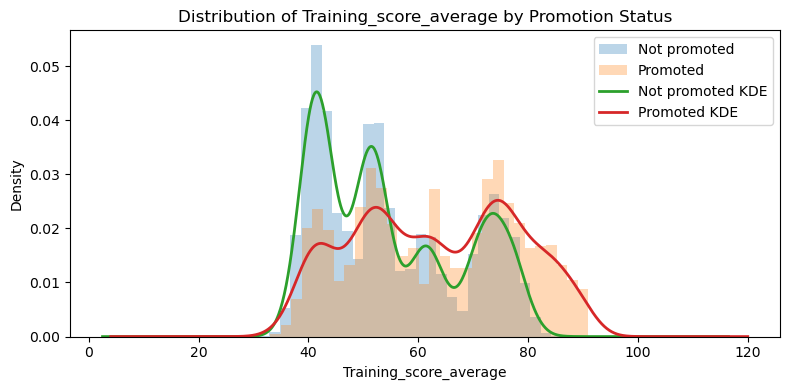

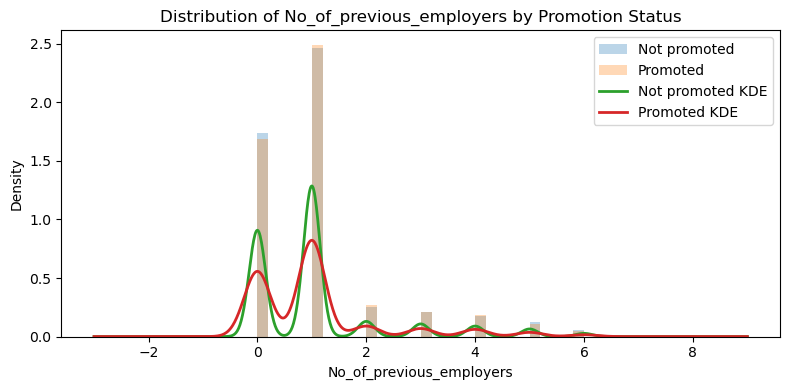

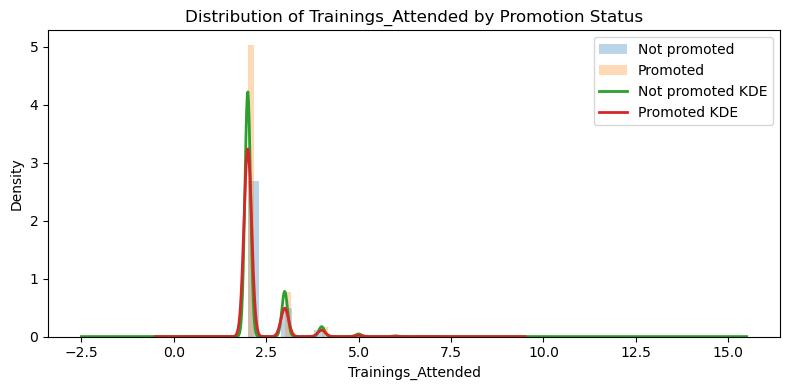

In [63]:

# Looping through the numeric columns 

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    ax = plt.gca()
    
    #Splitting the target column inside the loop
    not_promoted = df_pro[df_pro[target] == 0][col].dropna()
    promoted = df_pro[df_pro[target] == 1][col].dropna()
    
    # HISTOGRAMS for Distribution
    ax.hist(not_promoted, bins=30, alpha=0.3, density=True, label='Not promoted')
    ax.hist(promoted, bins=30, alpha=0.3, density=True, label='Promoted')

    # KDE LINES for Smooth comparison
    not_promoted.plot.kde(ax=ax, linewidth=2, label='Not promoted KDE')
    promoted.plot.kde(ax=ax, linewidth=2, label='Promoted KDE')

    ax.set_title(f'Distribution of {col} by Promotion Status')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

The age distribution shows that most employees fall between 35 and 55 years.
Both groups peak around 35 - 40 years becuase this is where the density is highest. The KDE curves for both groups also have similar age distributions.

Very few employees below ~25 or above ~60. And older employees appear in both groups. 

>“The age distributions of promoted and non-promoted employees show substantial overlap, with nearly identical peaks and spread. This indicates that promotion decisions are not strongly influenced by employee age, suggesting age-neutral promotion practices.”


#### 4c. Correlation heatmap for numeric features and the target

Correlation matrix:


,Age,Tenure,Trainings_Attended,Last_performance_score,Training_score_average,No_of_previous_employers,Promoted_or_Not
Age,1.000000,0.654666,-0.078710,0.175572,-0.048390,0.003117,-0.017991
Tenure,0.654666,1.000000,-0.056215,0.190333,-0.037477,0.003550,-0.012287
Trainings_Attended,-0.078710,-0.056215,1.000000,-0.062042,0.041065,0.000796,-0.024345
Last_performance_score,0.175572,0.190333,-0.062042,1.000000,0.057836,-0.005428,0.119690
Training_score_average,-0.048390,-0.037477,0.041065,0.057836,1.000000,0.008194,0.178448
No_of_previous_employers,0.003117,0.003550,0.000796,-0.005428,0.008194,1.000000,0.001690
Promoted_or_Not,-0.017991,-0.012287,-0.024345,0.119690,0.178448,0.001690,1.000000


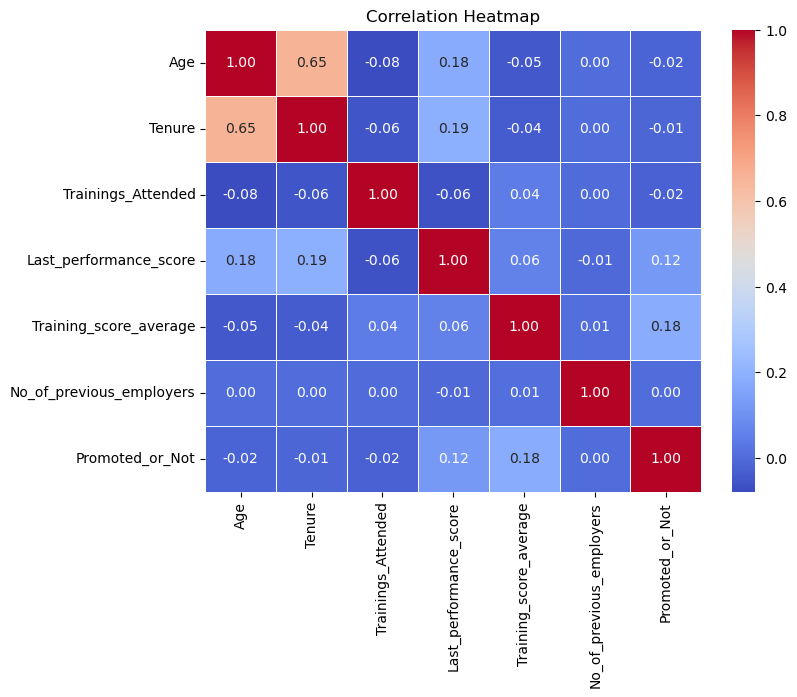

In [64]:
num_candidates = ['Age','Tenure','Trainings_Attended','Last_performance_score','Training_score_average','No_of_previous_employers', target]
cols_corr = [c for c in num_candidates if c in df_pro.columns]
corr = df_pro[cols_corr].corr()

print("Correlation matrix:")
display(corr)

# Simple heatmap using matplotlib
plt.figure(figsize=(8,6))
sns.heatmap(
    corr, 
    annot=True,          # show numbers on the heatmap
    cmap='coolwarm',     # bright red/blue color scale
    linewidths=0.5, 
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Use bright colors (blue = negative, red = positive)

“Correlation analysis indicates that numeric features exhibit limited linear relationships with promotion outcomes. Only Training_score_average (0.18) and Last_performance_score (0.12) show weak positive correlations. 

In contrast, categorical variables such as Division and Qualification demonstrate more pronounced differences in promotion rates, suggesting that promotion decisions are largely driven by organizational and role-specific factors rather than individual numeric attributes alone.”

In [65]:
df_pro.isna().sum()

EmployeeNo                             0
Division                               0
Qualification                          0
Gender                                 0
Channel_of_Recruitment                 0
Trainings_Attended                     0
Year_of_birth                          0
Last_performance_score                 0
Year_of_recruitment                    0
Targets_met                            0
Previous_Award                         0
Training_score_average                 0
State_Of_Origin                        0
Foreign_schooled                       0
Marital_Status                         0
Past_Disciplinary_Action               0
Previous_IntraDepartmental_Movement    0
No_of_previous_employers               0
Promoted_or_Not                        0
Qualification_missing                  0
Age                                    0
Tenure                                 0
dtype: int64

### Feature Engineering & Selection 

Our target variable is "promoted_or_Not", so we will split the data into;

In [66]:
categorical_cols = df_pro.select_dtypes(include='object').columns.tolist()
categorical_cols


['EmployeeNo',
 'Division',
 'Qualification',
 'Gender',
 'Channel_of_Recruitment',
 'State_Of_Origin',
 'Foreign_schooled',
 'Marital_Status',
 'Past_Disciplinary_Action',
 'Previous_IntraDepartmental_Movement']

In [67]:
# Exclude the EmployeeNo column
categorical_cols.remove('EmployeeNo')

In [68]:
numeric_features = [
    'Age',
    'Tenure',
    'Trainings_Attended',
    'Last_performance_score',
    'Training_score_average',
    'No_of_previous_employers'
]

numeric_features

['Age',
 'Tenure',
 'Trainings_Attended',
 'Last_performance_score',
 'Training_score_average',
 'No_of_previous_employers']

In [69]:
target = 'Promoted_or_Not'

These are numeric values and the models can use them directly
we will just scale them

### Encode Binary Categorical variables
They will be converted to 0 and 1, not one-hot encoded

In [70]:
df_pro.head()

,EmployeeNo,Division,Qualification,Gender,Channel_of_Recruitment,Trainings_Attended,Year_of_birth,Last_performance_score,Year_of_recruitment,Targets_met,...,State_Of_Origin,Foreign_schooled,Marital_Status,Past_Disciplinary_Action,Previous_IntraDepartmental_Movement,No_of_previous_employers,Promoted_or_Not,Qualification_missing,Age,Tenure
0,YAK/S/00001,Commercial Sales and Marketing,MSc MBA and PhD,Female,Direct Internal process,2,1986,12.5,2011,1,...,ANAMBRA,No,Married,No,No,0,0,0,39,14
1,YAK/S/00002,Customer Support and Field Operations,First Degree or HND,Male,Agency and others,2,1991,12.5,2015,0,...,ANAMBRA,Yes,Married,No,No,0,0,0,34,10
2,YAK/S/00003,Commercial Sales and Marketing,First Degree or HND,Male,Direct Internal process,2,1987,7.5,2012,0,...,KATSINA,Yes,Married,No,No,0,0,0,38,13
3,YAK/S/00004,Commercial Sales and Marketing,First Degree or HND,Male,Agency and others,3,1982,2.5,2009,0,...,NIGER,Yes,Single,No,No,1,0,0,43,16
4,YAK/S/00006,Information and Strategy,First Degree or HND,Male,Direct Internal process,3,1990,7.5,2012,0,...,AKWA IBOM,Yes,Married,No,No,1,0,0,35,13


In [71]:
df_encoded = df_pro.copy()

In [72]:
df_encoded.shape

(38312, 22)

In [73]:
#Encode Gender column
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})


In [74]:
df_encoded['Gender'].isna().sum()


0

In [75]:
df_encoded.shape

(38312, 22)

In [76]:

yes_no_map = {'Yes' : 1 , 'No': 0}

binary_col = [
    'Foreign_schooled',
    'Past_Disciplinary_Action',
    'Previous_IntraDepartmental_Movement'
]

for col in binary_col:
    df_encoded[col] = df_encoded[col].map(yes_no_map)

In [77]:
df_encoded.shape

(38312, 22)

### Encoding Multi-Class Categorical Variables using One-hot encode

In [78]:
multi_cat_cols = [
    'Marital_Status',
    'Division',
    'Qualification',
    'Channel_of_Recruitment',
    'State_Of_Origin'
]

df_encoded = pd.get_dummies(
    df_encoded,
    columns=multi_cat_cols,
    drop_first=True
)


We use drop_first = True to avoid redundancy and prevents multicollinearity which is important for linear models

Also becuase EmployeeNo is just an identifier and has no predictive meaning, including it can mislead the model


In [79]:
# preview the encoded datase
df_encoded.isna().sum().sum()

0

In [80]:
df_encoded.columns

Index(['EmployeeNo', 'Gender', 'Trainings_Attended', 'Year_of_birth',
       'Last_performance_score', 'Year_of_recruitment', 'Targets_met',
       'Previous_Award', 'Training_score_average', 'Foreign_schooled',
       'Past_Disciplinary_Action', 'Previous_IntraDepartmental_Movement',
       'No_of_previous_employers', 'Promoted_or_Not', 'Qualification_missing',
       'Age', 'Tenure', 'Marital_Status_Not_Sure', 'Marital_Status_Single',
       'Division_Commercial Sales and Marketing',
       'Division_Customer Support and Field Operations',
       'Division_Information Technology and Solution Support',
       'Division_Information and Strategy', 'Division_People/HR Management',
       'Division_Regulatory and Legal services',
       'Division_Research and Innovation', 'Division_Sourcing and Purchasing',
       'Qualification_MSc  MBA and PhD',
       'Qualification_Non University Education', 'Qualification_Unknown',
       'Channel_of_Recruitment_Direct Internal process',
       'Chan

### Dataset Split

In [81]:
target = 'Promoted_or_Not'

In [82]:
X = df_encoded.drop(columns = [target])

y = df_encoded[target]

In [83]:
# Including all object column sinto the X

X.select_dtypes(include = 'object').columns

Index(['EmployeeNo'], dtype='object')

In [84]:
X = X.drop(columns = ['EmployeeNo'])

In [85]:
X.shape


(38312, 66)

In [86]:
y.shape

(38312,)

### 6. Model Development
6.1 Model Choice

Logistic Regression was selected because:

It is interpretable, Suitable for binary classification and provides clear feature influence (coefficients)

6.2 Handling Class Imbalance

Used class_weight='balanced' and focused evaluation on Recall for promoted employees

6.3 Threshold Optimization

Instead of the default 0.5 probability threshold, a 0.3 threshold was used to:

Reduce false negatives and capture more deserving promotion candidates

### Step 8: Train-Test Split

We will split so we can test the model on unseen data

In [87]:

from sklearn.model_selection import train_test_split

# Split the  data into training and 20% for  testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


### Apply Standard Scaling to scale numeric features
Using so the model converges better and stratify=y to ensures the train/test sets have the same class distribution


In [88]:
# 3. Scale features (using standardscaler 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [92]:
X_train[numeric_features]

,Age,Tenure,Trainings_Attended,Last_performance_score,Training_score_average,No_of_previous_employers
10755,1.717497,2.859228,-0.414642,0.610439,-0.774144,-0.036408
4933,-0.368767,0.269031,-0.414642,-0.057585,-0.699376,-0.036408
8028,-1.933465,-1.143803,-0.414642,-2.061658,-1.222751,-0.842086
1953,-0.368767,-0.672858,1.215052,-1.393633,-0.250769,-0.036408
32336,0.152799,-0.908331,-0.414642,-0.057585,-0.848912,-0.036408
...,...,...,...,...,...,...
23514,0.413582,0.739976,-0.414642,0.610439,-0.624608,-0.036408
36605,0.413582,0.975448,1.215052,-0.057585,-0.325537,-0.842086
30611,-1.020724,-0.437386,1.215052,-0.057585,-0.774144,-0.842086
25957,-0.368767,0.033559,-0.414642,1.278464,1.244586,-0.842086


### Baseline Model: Logistic Regression

Becuase we are working with a classification data, we will be using logistics regression becuase its simple, interpretable and excellent baseline for classification.

The solver chosen is liblinera  becuase it works well with the many features, handle the class imbalance for promotion rate and more stabel convergence

In [98]:
#importing the logistics regression model

from sklearn.linear_model import LogisticRegression

In [101]:
# 4. Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train[numeric_features], y_train)

LogisticRegression(random_state=42)

In [103]:
# 5. Make predictions
y_pred = log_reg.predict(X_test[numeric_features])

In [110]:
# Importing Evaluation Libraries

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


### 7. Model Evaluation
7.1 Confusion Matrix Interpretation

The model correctly identifies most promoted employees

Some false positives exist, which is acceptable for HR shortlisting

Recall for promoted employees is high, aligning with business needs

7.2 Classification Report Insights

Accuracy is moderate and not the primary metric

Recall for promotion class is prioritized

Precision-recall trade-off is intentionally balanced for decision support

In [111]:
# 6. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.9154
Confusion Matrix:
[[7015    0]
 [ 648    0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      7015
           1       0.00      0.00      0.00       648

    accuracy                           0.92      7663
   macro avg       0.46      0.50      0.48      7663
weighted avg       0.84      0.92      0.88      7663



C:\Users\kolad\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kolad\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kolad\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [112]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000
)


log_model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

Logistic Regression uses numerical optimization under the hood and the optimizer struggles when numbers are on very different scales e.g Ages, Training_score_average

### Make Predictions: Using the test data

In [113]:
# 5. Make predictions
y_pred = log_model.predict(X_test)

In [114]:
y_pred

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [92]:
# 6. Evaluate the model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.6815
Confusion Matrix:
[[4607 2408]
 [  33  615]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.66      0.79      7015
           1       0.20      0.95      0.34       648

    accuracy                           0.68      7663
   macro avg       0.60      0.80      0.56      7663
weighted avg       0.93      0.68      0.75      7663



### Evaluation Metrics

1. Accuracy: The proportion of total predictions that were correct

    - Accuracy = 0.68 -> Out of 7,663 employees, the model predicted 68% correctly. i.e 648 (8.5%) were promoted and 7,015 weren't 
    


2. Confusion Matrix: Shows true vs predicted classification in the table above

4607 → Correctly predicted NOT promoted

2408 → Said promoted when they were NOT (false positives)

615 → Correctly predicted promoted

33 → Missed promotions (false negatives)

Class-by-Class Performance
Class 0 (Not Promoted)

Precision: 0.99 → When model says not promoted, it’s almost always right

Recall: 0.66 → It misses some non-promoted employees

F1-score: 0.79 → Strong performance overall

Class 1 (Promoted)

Precision: 0.20 → Many predicted promotions are wrong

Recall: 0.95 → It catches almost all actual promotions

F1-score: 0.34 → Weak balance due to many false positives

**What This Means in Business Terms**

✅ Great at not missing employees who should be promoted

⚠️ But it flags too many people as promotion-ready

Useful as a shortlisting or screening tool, not a final decision maker

In [115]:
y_probs = log_model.predict_proba(X_test)[:, 1]

In [116]:
y_probs

array([0.0637032 , 0.0968237 , 0.10704251, ..., 0.04137539, 0.4730111 ,
       0.84846993])

> This means “For each employee, give me the probability that they will be promoted.” Each number gives us the confidence of promotion

In [117]:
y_pred = (y_probs >= 0.3).astype(int)

In [118]:
y_pred

array([0, 0, 0, ..., 0, 1, 1])

> This means 'If promotion probability is 30% or more, the model will mark the employee as promotion-eligible'. This replaces the default 0.5 rule

## PART 2

### 2a.  Interpreting Coefficients to know what increases promotion odds?

In [122]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df


,Feature,Coefficient
7,Training_score_average,3.597935
17,Division_Commercial Sales and Marketing,3.081758
5,Targets_met,2.679621
21,Division_People/HR Management,2.531272
6,Previous_Award,1.809153
...,...,...
39,State_Of_Origin_EBONYI,-0.408238
24,Division_Sourcing and Purchasing,-2.215882
19,Division_Information Technology and Solution S...,-4.438303
20,Division_Information and Strategy,-5.680110


Coefficient	     Meaning
Positive (+)	 Increases promotion likelihood
Negative (-)	 Decreases promotion likelihood
Large magnitude	 Strong influence
Near 0	         Weak influence


🔼 Training_score_average, Division_commercial Sales and Marketing, Targets_met, Previous_Award, → higher promotion chance


🔽 Division_research and Innovation, Division_Information and Strtegy etc → hurts promotion


### 2b.  Feature Importance to know which features matters most overall?

In [123]:
coef_df['Importance'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='Importance', ascending=False)

coef_df_sorted.head(10)


,Feature,Coefficient,Importance
23,Division_Research and Innovation,-6.213021,6.213021
20,Division_Information and Strategy,-5.680110,5.680110
19,Division_Information Technology and Solution S...,-4.438303,4.438303
7,Training_score_average,3.597935,3.597935
17,Division_Commercial Sales and Marketing,3.081758,3.081758
5,Targets_met,2.679621,2.679621
21,Division_People/HR Management,2.531272,2.531272
24,Division_Sourcing and Purchasing,-2.215882,2.215882
6,Previous_Award,1.809153,1.809153
44,State_Of_Origin_GOMBE,0.564422,0.564422


### 2c. What the Model should be used for

“This model should be used as a promotion screening tool, not a final decision-maker.”


### 9. Model Comparison (Validation)

A Decision Tree model was also trained to validate patterns.

Findings:

Similar important features emerged

Confirms robustness of insights

Logistic Regression preferred due to better interpretability

### 3.  Compare with a Tree- based model to see of Logistic Regression is enough

We will be testing same dataset with a random Forest

#### Training the Random Forest

In [127]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

#### Evaluating the model

In [128]:
from sklearn.metrics import classification_report, confusion_matrix

rf_preds = rf.predict(X_test)

print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


[[7008    7]
 [ 485  163]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      7015
           1       0.96      0.25      0.40       648

    accuracy                           0.94      7663
   macro avg       0.95      0.63      0.68      7663
weighted avg       0.94      0.94      0.92      7663



7008 → Correctly predicted Not Promoted

7 → Incorrectly predicted promotion (very few false positives)

163 → Correctly predicted Promoted

485 → Missed promotions (false negatives)

👉 The model is very conservative about predicting promotions.

Class-by-Class Performance
Class 0 – Not Promoted

Precision: 0.94 → Predictions are very reliable

Recall: 1.00 → Almost all non-promoted employees identified

F1-score: 0.97 → Excellent

Class 1 – Promoted (Important Class)

Precision: 0.96 → When it predicts promotion, it’s usually correct

Recall: 0.25 → It only catches 25% of actual promotions

F1-score: 0.40 → Low due to many missed promotions

What This Means in Business Terms

✅ Very good at avoiding false promotions

❌ Misses 3 out of 4 employees who should be promoted

Best used when wrong promotions are costly, but missed promotions are acceptable

##### Feature Importance for the Random Forest

In [91]:
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance.head(10)


,Feature,Importance
7,Training_score_average,0.191560
5,Targets_met,0.149858
3,Last_performance_score,0.068334
2,Year_of_birth,0.058070
13,Age,0.057206
4,Year_of_recruitment,0.041356
14,Tenure,0.040630
11,No_of_previous_employers,0.034365
6,Previous_Award,0.033974
17,Division_Commercial Sales and Marketing,0.022819



### 8. Feature Importance & Interpretation
Key Drivers of Promotion

Strong Positive Influence; Last performance score, Meeting annual targets, Training score average, Previous awards

Strong Negative Influence: Past disciplinary actions, Poor performance history

Minimal Influence; Gender,Marital status

This suggests promotion decisions are performance-driven rather than demographic-based, supporting fairness.


### 10. Business Recommendations

Based on the analysis:

Prioritize performance and target achievement in promotion decisions

Focus on training quality, not just training attendance

Use the model as a shortlisting tool, not a replacement for HR judgment

Regularly retrain the model as new employee data becomes available

Monitor fairness metrics to ensure unbiased outcomes

### 11. Conclusion

This project successfully demonstrates how machine learning can:

Support fair and data-driven promotion decisions

Identify high-impact factors influencing career growth

Reduce human bias while improving efficiency

The model is interpretable, practical, and aligned with HR decision-making needs, making it suitable for real-world deployment as a decision-support system.